
# <span style="color:rgb(213,80,0)">Robust Adaptive Beamforming</span>

In adaptive beamforming, we not only need to know the AOA of expected signals, but also the exact steering vector, i.e. we need to know the radiation pattern of each antenna and their locations. The Capon (MVDR) beamformer is very sensitive to model mismatch errors. For example, we have a signal impinging from direction $\theta_0$ , according to signal model of narrow band signal, the received signal can be formulated as


 $x(n)=a_0 s[n]+i(n)+v(n)$ ,


however, because of the mismatch errors, the true received signal is


 $x(n)=a_{true} s[n]+i(n)+v(n)$ , and $a_{true} =a_0 +e$ , $e$ indicates the error vector that contains all possible errors causing the steering vector mismatches with the true steering vector. Normally, we assume that $a(\theta_0 )=a_0$ , but due to mismatch problem, $a(\theta_0 )=a_0 +e$ . But we can only know $a_0$ . If we apply Capon beamformer,


$$\left\lbrace \begin{array}{l} \min w^H {\hat{R} }_{xx} w\\ s.t.w^H a_0 =1 \end{array}\right.$$

The true array response to direction ${{\theta }}_0$ is


 $w^H a(\theta_0 )=w^H a_0 +w^H e$ . Considering a case when $w^H e=-1$ , then $w^H a=0$ . So the conventional Capon beamformer cannot work well when it's difficult to dismiss the mismatch errors of the array. That's why we need to introduce robust beamformer.


In [1]:
clearvars;
close all;
clc;
rng(7);

lambda = 3e-2;
M = 12;
position = (0:M-1).' * lambda/2;
steering = @(theta) ...
    exp(-1j*2*pi/lambda * position * sind(theta));

% Simulation parameters
theta_nominal = 0;                 % Presumed desired-signal DOA (deg)
theta = [2.5, -20, 30];            % True desired and interference DOAs (deg)
SNR_dB = 0;
INR_dB = [20, 20];
K = 5000;                          % Number of snapshots
noise_power = 1;                   % Noise power at each sensor

A = steering(theta);
a_true = A(:,1);
Ps = noise_power * 10^(SNR_dB/10);
Pi = noise_power * 10.^(INR_dB/10);

noise_unit = (randn(M,K) + 1j*randn(M,K))/sqrt(2);
noise = sqrt(noise_power) * noise_unit;
u1 = (randn(1,K) + 1j*randn(1,K))/sqrt(2);
u2 = (randn(1,K) + 1j*randn(1,K))/sqrt(2);

data = randi([0, 3], 1, K);
s_unit = exp(1j*(pi/4 + pi/2*data));
s = sqrt(Ps) * s_unit;
i1 = sqrt(Pi(1)) * u1;
i2 = sqrt(Pi(2)) * u2;
S = [s; i1; i2];
X = A*S + noise;

## Diagonal\-loaded Capon beamforming

Consider a simple scenario, where due to miscalibration of array, the steering verctor $a(\theta_0 )$ of the desired signal takes form of a small angle error $\varepsilon$ , i.e. the assumed DOA of signal is $\theta_0$ , while the real one is $\theta_0 +\varepsilon$ . So if we using Capon beamformer for spatial filtering, the constraint $w^H a(\theta_0 )=1$ will make the desired signal an interference, which will cause a narrow and deep nulling to suppress the desired signal. But if we using diagonal loading, this phenomenan can be relieved. The typical optimziation problem of diagonal\-loaded Capon beamforming is formulated as


 $\left\lbrace \begin{array}{l} \min w^H (R_{xx} +\delta I)w\\ s.t.w^H a_0 =1 \end{array}\right.$ , where $\delta$ is the diagonal loaded factor, and it's a hyperparameter. Let's reorganize the formula as


$$\left\lbrace \begin{array}{l} \min w^H R_{xx} w+\delta w^H w\\ s.t.w^H a_0 =1 \end{array}\right.$$

so the new optimization problem has a regularization term of the norm of weight vector $w$ , which gives penalty to $w$ with large norm. Let's consider the difference between ideal and actual beamformer responses.


 $\Delta P=w^H (a_0 +e)-w^H a_0 =w^H e$ ,


so $|P|=|w^H e|$ , by applying Cauchy\-Schwarz inequality,


 $|P|=|w^H e|\le ||w||_2 ||e||_2$ , when $e$ is bounded by $||e||_2 \le \epsilon$ , then $|P|\le \epsilon ||w||_2$ , so when $||w||_2$ is larger, the maximum possible error also gets larger.


From another perspective, when $\varepsilon$ is small, the constraint guarantees $w^H a_0 =1$ , but in $\theta_0 +\varepsilon$ , which is the DOA of desired signal, $w^H a(\theta_0 +\varepsilon )$ can quickly change to near zero, and that will lead to a large value of derivative of beampattern.


 $|P(\theta )|^2 =w^H a(\theta )a^H (\theta )w$ , the derivative with respect to $\theta$ is


$$\begin{array}{l} \frac{d|P(\theta )|^2 }{d\theta }=\frac{d(w^H a(\theta ))}{d\theta }a^H (\theta )w+w^H a(\theta )\frac{d(a^H (\theta )w)}{d\theta }\\ =\frac{d(w^H a(\theta ))}{d\theta }a^H (\theta )w+[\frac{d(w^H a(\theta ))}{d\theta }a^H (\theta )w]^H \\ =2{\mathrm{R}\mathrm{e}}\lbrace w^H \frac{d(a(\theta ))}{d\theta }a^H (\theta )w\rbrace  \end{array}$$

due to the large value of derivative $\frac{d|P(\theta )|^2 }{d\theta }$ , and $\frac{d(a(\theta ))}{d\theta }a^H (\theta )$ is bounded, than the norm of $w$ should be of large value. That's why when we constrain the norm of $w$ by introducing a regularization term would contribute to constrain the value of $\frac{d|P(\theta )|^2 }{d\theta }$ , which can make the beampattern smooth, without forming a deep narrow nulling in the DOA of desired signal


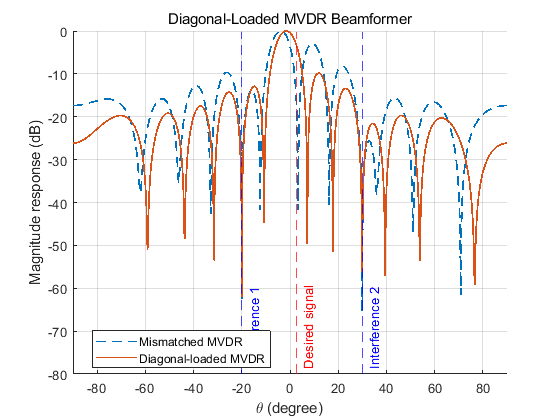

In [2]:
R_xx = X*X'/K;
R_xx = (R_xx + R_xx')/2;
a_0 = steering(theta_nominal);

% Conventional (delay-and-sum) beamformer
w_cbf = a_0/(a_0'*a_0);

% Mismatched MVDR beamformer
q_mvdr = R_xx\a_0;
w_opt_1 = q_mvdr/(a_0'*q_mvdr);

% Diagonally loaded MVDR beamformer.  The loading is specified relative
% to the average received power per sensor.
loading_ratio = 0.05;
loading_level = loading_ratio * real(trace(R_xx))/M;
R_xx_loaded = R_xx + loading_level*eye(M);
q_loaded = R_xx_loaded\a_0;
w_opt_2 = q_loaded/(a_0'*q_loaded);

theta_plot = -90:0.1:90;
D_plot = steering(theta_plot);
P_0 = w_opt_1'*D_plot;
BP_0 = 20*log10(abs(P_0)/max(abs(P_0)) + eps);
P_1 = w_opt_2'*D_plot;
BP_1 = 20*log10(abs(P_1)/max(abs(P_1)) + eps);

figure;
hold on;
h_MVDR = plot(theta_plot, BP_0, 'LineWidth', 1.3, 'LineStyle', '--');
h_MVDRloaded = plot(theta_plot, BP_1, 'LineWidth', 1.3, 'LineStyle', '-');
grid on;
xlim([-90 90]);
ylim([-80 0]);
h_desired = xline(theta(1), 'r--', 'Desired signal', ...
    'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
h_interf = gobjects(1, numel(theta)-1);
for ii = 2:numel(theta)
    h_interf(ii-1) = xline(theta(ii), 'b--', ...
        sprintf('Interference %d', ii-1), ...
        'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
end
xlabel('\theta (degree)');
ylabel('Magnitude response (dB)');
title('Diagonal-Loaded MVDR Beamformer');
legend([h_MVDR, h_MVDRloaded], ...
    {'Mismatched MVDR', 'Diagonal-loaded MVDR'}, 'Location', 'best');

In [3]:

fprintf('|w_mvdr^H a_true|        = %.6f\n', abs(w_opt_1'*a_true));

|w_mvdr^H a_true|        = 

0.271120

In [4]:
fprintf('|w_mvdr_loaded^H a_true| = %.6f\n\n', abs(w_opt_2'*a_true));

|w_mvdr_loaded^H a_true| = 

0.739900

## Worst\-case robust beamforming

In diagonal\-loaded MVDR beamforming, the diagonal loading factor $\delta$ can't adaptively adjust to the practical application. So we introduce an wide\-used techique called worst\-case robust beamforming.


We assume that, the difference between real steering vector and ideal steering vector is bounded by $||e||_2 \le \varepsilon$ , that is to say, the real steering vectors belong to a spherical set:


 $\mathcal{A}:\lbrace a_0 +e:||e||_2 \le \varepsilon \rbrace$ , which means, the real steering vectors fall into a high\-dimensional ball whose center is the ideal steering vectors.


According to MVDR beamformer


 $\left\lbrace \begin{array}{l} \min w^H {\hat{R} }_{xx} w\\ s.t.w^H a_0 =1 \end{array}\right.$ , we can't only protect only $a_0 =a(\theta_0 )$ , where $\theta_0$ is the estimated doa of desired signal, because the steering vector is not accurate, instead, we need to protect all steering vectors belongs to the uncertain set $\mathcal{A}$ . Here we don't take the phase of beam response, because under the assumption of far\-field narrow band signal, the phase shift introduced by array response usually performs as an entire phase shift of the signal which can be easily compensated, but in wideband beamforming we can't directly apply this idea, because in wideband beamforming we need to coherently integrate subband signals. Because in this case the beampattern would be a function with respect to frequency, and it can add different phase shift to different frequency conponents, which can cause waveform distortion. But here the beampattern is a function with respect to doa $\theta$ , and it can be regarded as a constant with respect to frequency $\omega$ . So one direct constraint is to let the absolute value of beam response to the steering vectors in $\mathcal{A}$ larger than 1. Because here we only consider the  power and SINR of the output signal. So the new optimization problem can be rewritten as


$$\left\lbrace \begin{array}{ll} \min  & w^H {\hat{R} }_{xx} w\\ s.t. & |w^H a|\ge 1 \end{array}\right.$$

However, this problem cannot be solved, because the constraint contains infinite constraints, which means all steering vectors in $\mathcal{A}$ should be under this constraint.


Rewriting the constraints by separate the real steering vector.


 $|w^H a|=|w^H a_0 +w^H e|\ge 1$ . Applying triangle inequality


 $|w^H a_0 +w^H e|\ge |w^H a_0 |-|w^H e|$ . Then applying Cauchy\-Schwarz inequality $|w^H e|\le ||w||_2 ||e||_2 \le \varepsilon ||w||_2$ , so


 $|w^H a_0 +w^H e|\ge |w^H a_0 |-\varepsilon ||w||_2$ .


This lower bound can be attained when,


 $w^H a_0 =|w^H a_0 |e^{j\phi } ,e=-\varepsilon \frac{w}{||w||_2 }e^{j\phi }$ , which means the real steering vector is just opposite to the ideal one.


Hence,


 $\min_{||e||_2 \le \varepsilon } |w^H (a_0 +e)|=\max \lbrace |w^H a_0 |-\varepsilon ||w||_2 ,0\rbrace$ ,


because the constraint is larger than 1. so the equivalent constraint is


$$|w^H a_0 |-\varepsilon ||w||_2 \ge 1$$

Then the optimization problem can be rewritten as


$$\left\lbrace \begin{array}{ll} \min  & w^H {\hat{R} }_{xx} w\\ s.t. & |w^H a_0 |\ge \varepsilon ||w||_2 +1 \end{array}\right.$$

But this is not a convex problem, which is difficult to solve, so the next step is to convert it to a convex problem


Noticing that the phase shift of weight vector $w$ will not affect the value of cost function, and when we obtain the optimal $w_0$ , we can always shift the phase to make $|w^H a_0 |$ real. So without loss of generality(W.L.O.G.), we can always select the $w$ to make $w^H a_0$ real. So ${\mathrm{I}\mathrm{m}}\lbrace w^H a_0 \rbrace =0$ . Thus, we can rewrite the problem as


$$\left\lbrace \begin{array}{ll} \min  & w^H {\hat{R} }_{xx} w\\ s.t. & {\mathrm{R}\mathrm{e}}\lbrace w^H a_0 \rbrace \ge \varepsilon ||w||_2 +1,\\  & {\mathrm{I}\mathrm{m}}\lbrace w^H a_0 \rbrace =0 \end{array}\right.$$

This is a typical second\-order cone program problem, and it can be solved by CVX methods, by using CVX toolbox.


Next, I will prove the problem is a SOCP problem.


In  *Convex Optimization* by Boyd, the typical SOCP problem is expressed as


$$\left\lbrace \begin{array}{ll} \min  & f^T x\\ s.t. & ||A_i x+b_i ||_2 \le c_i^T x+d_i \\  & Fx=g \end{array}\right.$$

By applying Cholesky factorization of ${\hat{R} }_{xx}$ , we obtain


 ${\hat{R} }_{xx} =U^H U$ ,


Then $w^H {\hat{R} }_{xx} w=||{Uw}||_2^2$ , apprantly ,minimizing $||{Uw}||_2^2$ is equivalent to minimizing $||{Uw}||_2$ . By introducing the upper bound of $||{Uw}||_2 \le \tau$ , the beamforming problem can be rewritten to


$$\left\lbrace \begin{array}{ll} \min  & \tau \\ s.t. & ||{Uw}||_2 \le \tau \\  & {\mathrm{R}\mathrm{e}}\lbrace w^H a_0 \rbrace \ge \varepsilon ||w||_2 +1,\\  & {\mathrm{I}\mathrm{m}}\lbrace w^H a_0 \rbrace =0 \end{array}\right.$$

Generally, optimization problem is expressed as a real\-value problem. Thus, we define


 $\begin{array}{l} w=u+jv,\\ U=U_R +jU_I  \end{array}$ . The real independent variable vector is


 ${\xi }=\left\lbrack \begin{array}{c} u\\ v\\ \tau  \end{array}\right\rbrack$ . Define $\tilde{U} =\left\lbrack \begin{array}{cc} U_R  & -U_I \\ U_I  & U_R  \end{array}\right\rbrack$ , $a_0 =p+jq$ . Thus

 $ \left\lbrace \begin{array}{l} \tau ={\left\lbrack \begin{array}{c} 0_{2M\times 1} \\ 1 \end{array}\right\rbrack }^T {\xi }\\
||\left\lbrack \begin{array}{cc} \tilde{U}  & 0_{2M\times 1}  \end{array}\right\rbrack {\xi }||_2 \le {\left\lbrack \begin{array}{c} 0_{2M\times 1} \\ 1 \end{array}\right\rbrack }^T {\xi }\\
||\left\lbrack \begin{array}{cc} \varepsilon I_{2M\times 2M}  & 0_{2M\times 1}  \end{array}\right\rbrack {\xi }||_2 \le {\left\lbrack \begin{array}{c} p\\ q\\ 0 \end{array}\right\rbrack }^T {\xi }-1\\
\left\lbrack \begin{array}{ccc} q^T  & -p^T  & 0 \end{array}\right\rbrack {\xi }=0
\end{array}\right. $

Define

 $ \left\lbrace \begin{array}{l} f=\left\lbrack \begin{array}{c} 0_{2M\times 1} \\ 1 \end{array}\right\rbrack \\
A_1 =\left\lbrack \begin{array}{cc} \tilde{U}  & 0_{2M\times 1}  \end{array}\right\rbrack ,c_1 =\left\lbrack \begin{array}{c} 0_{2M\times 1} \\ 1 \end{array}\right\rbrack \\
A_2 =\left\lbrack \begin{array}{cc} \varepsilon I_{2M\times 2M}  & 0_{2M\times 1}  \end{array}\right\rbrack ,c_2 =\left\lbrack \begin{array}{c} p\\ q\\ 0 \end{array}\right\rbrack \\
F=\left\lbrack \begin{array}{ccc} q^T  & -p^T  & 0 \end{array}\right\rbrack
\end{array}\right. $

So this is a typical SOCP problem. But by applying CVX toolbox, we don't have to convert it to the standard form. $\left\lbrace \begin{array}{ll} \min  & w^H {\hat{R} }_{xx} w\\ s.t. & {\mathrm{R}\mathrm{e}}\lbrace w^H a_0 \rbrace \ge \varepsilon ||w||_2 +1,\\  & {\mathrm{I}\mathrm{m}}\lbrace w^H a_0 \rbrace =0 \end{array}\right.$ would be enough for CVX to solve.


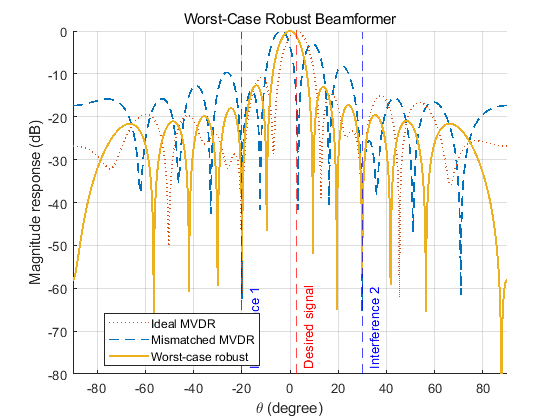

In [5]:
theta0 = theta_nominal;
a0 = steering(theta0);
Delta_theta = 3;                   % DOA uncertainty half-width (deg)
theta_unc = linspace(theta0-Delta_theta, theta0+Delta_theta, 2001);
A_unc = steering(theta_unc);
epsilon_wc = max(vecnorm(A_unc-a0, 2, 1));

if epsilon_wc >= norm(a0)
    error(['The uncertainty radius must be smaller than norm(a0); ' ...
        'otherwise the worst-case robust problem is infeasible.']);
end

cvx_clear
cvx_begin quiet
    variable w_wc(M) complex
    minimize(quad_form(w_wc, R_xx))
    subject to
        real(w_wc' * a0) >= 1 + epsilon_wc * norm(w_wc, 2);
        imag(w_wc' * a0) == 0;
cvx_end

if ~contains(cvx_status, 'Solved')
    error('CVX failed to solve the worst-case robust problem. Status: %s', cvx_status);
end

% Oracle MVDR: benchmark only; it uses the true desired-signal steering vector.
a_ideal = a_true;
q_ideal = R_xx\a_ideal;
w_ideal = q_ideal/(a_ideal'*q_ideal);

P_wc = w_wc'*D_plot;
BP_wc = 20*log10(abs(P_wc)/max(abs(P_wc)) + eps);
P_ideal = w_ideal'*D_plot;
BP_ideal = 20*log10(abs(P_ideal)/max(abs(P_ideal)) + eps);

figure;
hold on;
h_MVDR_mismatched = plot(theta_plot, BP_0, 'LineWidth', 1.3, 'LineStyle', '--');
h_MVDR_ideal = plot(theta_plot, BP_ideal, 'LineWidth', 1.3, 'LineStyle', ':');
h_MVDR_wc = plot(theta_plot, BP_wc, 'LineWidth', 1.5, 'LineStyle', '-');
grid on;
xlim([-90 90]);
ylim([-80 0]);
xline(theta(1), 'r--', 'Desired signal', ...
    'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
for ii = 2:numel(theta)
    xline(theta(ii), 'b--', sprintf('Interference %d', ii-1), ...
        'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
end
xlabel('\theta (degree)');
ylabel('Magnitude response (dB)');
title('Worst-Case Robust Beamformer');
legend([h_MVDR_ideal, h_MVDR_mismatched, h_MVDR_wc], ...
    {'Ideal MVDR', 'Mismatched MVDR', 'Worst-case robust'}, ...
    'Location', 'best');

In [6]:

fprintf('|w_mvdr^H a_true| = %.6f\n', abs(w_opt_1'*a_true));

|w_mvdr^H a_true| = 

0.271120

In [7]:
fprintf('|w_wc^H a_true|   = %.6f\n\n', abs(w_wc'*a_true));

|w_wc^H a_true|   = 

37.907976


However, the error bound $\varepsilon$ is also bounded. Beacuse $||e||_2 \le \varepsilon$ , if $\varepsilon \ge ||a_0 ||_2$ , than $\mathcal{A}$ may contain $-a_0$ , so according to the original constraint $|w^H 0|\ge 1$ ,which is impossible. So we need to make sure that $\varepsilon \le ||a_0 ||_2$ .

## Robust Adaptive Beamforming Based on Interference Covariance Matrix Reconstruction and Steering Vector  Estimation（*IEEE. Trans. Sig. Proc. Y.J. Gu & A. Leshem*）

Another way for robust adaptive beamforming is to reconstruct covariance matrix and steering vector. Here I will introduce another method of robust capon beamformer.


MVDR beamformer using the interference plus noise covariance matrix o obtain the optimal weight vector. So a direct idea for robust adaptive beamforming is to reconstruct interference plus noise covariance matrix through prior knowlede of the nominal DOA interval. Consider the MPDR beamformer


 $\left\lbrace \begin{array}{l} \min w^H {\hat{R} }_{xx} w\\ s.t.w^H a_0 =1 \end{array}\right.$ , $w_{opt} =\frac{R_{xx}^{-1} d(\theta )}{d(\theta )^H R_{xx}^{-1} d(\theta )}$ , where $d(\theta )$ is the ideal steering vector obtained from the geomitry of antenna array. Substituting the oprimal weight vector to the objective function.


 $P(\theta )=(\frac{R_{xx}^{-1} w}{w^H R_{xx}^{-1} w})^H R_{xx} (\frac{R_{xx}^{-1} w}{w^H R_{xx}^{-1} w})$ . Because covariance matrix $R_{xx}$ is Hermitian, so $R_{xx}^H =R_{xx}$ , the power with respect to DOA is called Capon spatial spectrum.


 $\hat{P} (\theta )=\frac{1}{d(\theta )^H R_{xx}^{-1} d(\theta )}$ .  According to the definition of covariance matirx.


$$\begin{array}{l} R_{xx} =E[x(k)x(k)^H ]\\ =E\lbrace [x_s (k)+x_i (k)+x_n (k)][x_s (k)+x_i (k)+x_n (k)]^H \rbrace \\ =E\lbrace [a_s s(k)+\sum_{l=1}^L a_l I_l (k)+n(k)][a_s s(k)+\sum_{l=1}^L a_l I_l (k)+n(k]^H \rbrace  \end{array}$$

Assuming that the desired signal, interferences and noise are independent to each other. So the covariance matrix can be rewrite to


 $R_{xx} =\sigma_s^2 a_s a_s^H +\sum_{l=1}^L \sigma_l^2 a_l a_l^H +\sigma_n^2 I$ . So one way to reconstruct interference plus noise covariance matrix is to delete the desired signal part of covariance matrix. However, the power of interference, noise are unknow. So we use Capon spaial spectrum for subsitution. After estimating the DOA interval of desired signal through prior condition, we can separate the desired signal interval $\Theta$ from the whole spatial region. The left part $\bar{\Theta}$ would only contain noise and interference. Then we can reconstruct interference\-plus\-noise covariance matrix


$${\hat{R} }_{i+n} =\int_{\bar{\Theta} } \hat{P} (\theta )d(\theta )d(\theta )^H d\theta$$

In [8]:
theta_scan = -90:0.1:90;
d = steering(theta_scan);
P_capon = zeros(numel(theta_scan),1);

% A very small loading improves numerical stability of the Capon spectrum.
for ii = 1:numel(theta_scan)
    d_temp = d(:,ii);
    q_temp = R_xx\d_temp;
    P_capon(ii) = real(1/(d_temp'*q_temp));
end

% Remove the entire prior SOI sector before reconstructing interference+noise.
theta_soi_sector = [theta_nominal-5, theta_nominal+5];
idx_out_sector = theta_scan < theta_soi_sector(1) | ...
    theta_scan > theta_soi_sector(2);
R_IpN_recon = zeros(M,M);
out_indices = find(idx_out_sector);
dtheta_rad = deg2rad(theta_scan(2)-theta_scan(1));
for kk = 1:numel(out_indices)
    q = out_indices(kk);
    dq = d(:,q);
    R_IpN_recon = R_IpN_recon + ...
        P_capon(q)*(dq*dq')*dtheta_rad;
end

% Enforce a Hermitian positive-definite reconstructed covariance matrix.
R_IpN_recon = (R_IpN_recon + R_IpN_recon')/2;
reconstruction_loading_ratio = 1e-3;
reconstruction_loading = reconstruction_loading_ratio * ...
    real(trace(R_IpN_recon))/M;
R_IpN_recon = R_IpN_recon + ...
    max(reconstruction_loading, 1e-10)*eye(M);


Supppose the estimated DOA of desired signal is $\theta_0$ , true DOA is $\theta_0 +\Delta \theta$ . We define the nominal steering vector $\bar{a} =d(\theta_0 )$ . According to MVDR beamformer, the optimal weight vector is


 $w_{Rec} =\frac{{\hat{R} }_{i+n}^{-1} \bar{a} }{{\bar{a} }^H {\hat{R} }_{i+n}^{-1} \bar{a} }$ . However, there is difference between the real steering vector $d(\theta +\Delta \theta )$ , therefore, we still need to estimate the actual steering vector of signal of interest(SOI) using the reconstructed covariance matrix ${\hat{R} }_{i+n}$


In this paper, autors defined the objective function as a Capon\-like sptial spectrum


 $\widetilde{P} (a)=\frac{1}{a^H {\hat{R} }_{i+n}^{-1} a}$ . And the optimal steering vector can be estimated by maximizing $\widetilde{P} (a)$ (which I really don't know why). Equivalently, minimizing the denominator. But we need to exclude the trivial solution $a=0$ , thus we need to find the appropriate constraint.


Suppose the true steering vector $a=\bar{a} +e$ . Let us consider the inner product of $a$ and the ideal steering vector $d(\theta )$ , because inner product can be regarded as a similarity measurement of vectors. After correction, we want the optimal steering vector not to increase its similarity to steering vector of interference, because inner product of complex vectors is complex, we use absolute value to indicate such similarity, i.e.


 $|a^H d(\theta )|\le |{\bar{a} }^H d(\theta )|$ for all $\theta \in \bar{\Theta}$ . This constraint is infinite, because it gives a constraint to every angle $\theta \in \bar{\Theta}$ , we need to convert it into a single constraint. Equivalently, the inequality can be rewritten as the square of the both sides $|a^H d(\theta )|^2 \le |{\bar{a} }^H d(\theta )|^2$ . Moving the right part to the left, we can obtain $|a^H d(\theta )|^2 -|{\bar{a} }^H d(\theta )|^2 \le 0$ . If we integrate the inequality with respect to $\theta \in \bar{\Theta}$ , we shall obtain a single costraint


 $\int_{\bar{\Theta} } [|a^H d(\theta )|^2 -|{\bar{a} }^H d(\theta )|^2 ]d\theta \le 0$ . However, this inequality indicates that, the average similarity between variable $a$ and steering vectors $d(\theta )$ in the angle domain $\bar{\Theta}$ . It is possible that the optimal $a$ will lean toward the direction with high interference, because we don't give panalty to the direction with inerference. So a weighted integration needs to be used to suppress the possiblity of leaning toward interference direction for $a_{opt}$


 $\int_{\bar{\Theta} } c(\theta )[|a^H d(\theta )|^2 -|{\bar{a} }^H d(\theta )|^2 ]d\theta \le 0$ . One direct idea for $c(\theta )$ is the Capon spatial spectrum $c(\theta )=\hat{P} (\theta )$ . This will give a regularization of the direction of strong interference, which can still meet the constraint of non\-wighted inequality. Apart from that, we can rewrite the inequality as


$$\begin{array}{l} \int_{\bar{\Theta} } ~\hat{P} (\theta )[|a^H d(\theta )|^2 -|{\bar{a} }^H d(\theta )|^2 ]d\theta \\ =\int_{\bar{\Theta} } ~\hat{P} (\theta )[a^H d(\theta )d^H (\theta )a-{\bar{a} }^H d(\theta )d^H (\theta )\bar{a} ]d\theta \\ =a^H \left\lbrack \int_{\bar{\Theta} } ~\hat{P} (\theta )d(\theta )d^H (\theta )\right\rbrack d\theta a-{\bar{a} }^H \left\lbrack \int_{\bar{\Theta} } ~\hat{P} (\theta )d(\theta )d^H (\theta )\right\rbrack \bar{a} d\theta \\ =a^H {\hat{R} }_{i+n} a-{\bar{a} }^H {\hat{R} }_{i+n} \bar{a}  \end{array}$$

so the whole optimization problem is


$$\left\lbrace \begin{array}{ll} \min_a  & a^H {\hat{R} }_{i+n}^{-1} a\\ s.t. & a^H {\hat{R} }_{i+n} a\le {\bar{a} }^H {\hat{R} }_{i+n} \bar{a}  \end{array}\right.$$

But this problem still have a trivial solution $a=0$ which can meet the constraint. Because the definition $a=\bar{a} +e$ contains the parallel component and vertical component, $a=\bar{a} +e_{\parallel } +e_{\perp }$ , where $e_{\parallel } =\alpha \bar{a} ,\langle e_{\perp } ,\bar{a} \rangle =0$ . So we need to constraint the modulus of the $a_{opt}$ in case that it won't lean toward $0$ .  The parallel component does not affect the output SINR severely, so there's no need to restrict it. We only consider $e_{\perp }$ which will affect the phase, or direction, of the steering vector. So rewrite the optimization problem as


 $\left\lbrace \begin{array}{ll} \min_{e_{\perp } }  & (\bar{a} +e_{\perp } )^H {\hat{R} }_{i+n}^{-1} (\bar{a} +e_{\perp } )\\ s.t. & (\bar{a} +e_{\perp } )^H {\hat{R} }_{i+n} (\bar{a} +e_{\perp } )\le {\bar{a} }^H {\hat{R} }_{i+n} \bar{a} \\  & {\bar{a} }^H e_{\perp } =0 \end{array}\right.$ . Because ${\hat{R} }_{i+n} \succ 0$ , it has inverse, so this is a quadratically constrained quadratic programming(QCQP) problem, which can be solved by CVX.


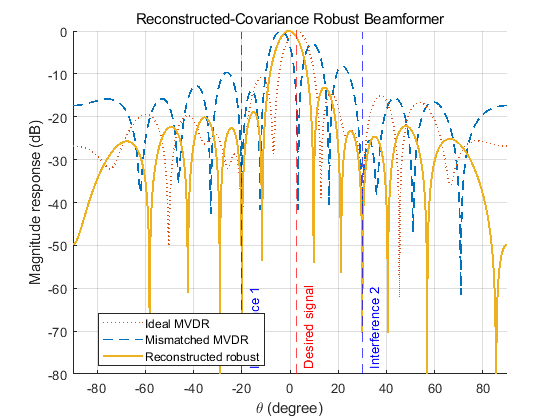

In [9]:
constraint_bound = real(a_0' * R_IpN_recon * a_0);
R_IpN_recon_inv = R_IpN_recon\eye(M);
% R_IpN_recon_inv = (R_IpN_recon_inv + R_IpN_recon_inv')/2;

cvx_clear
cvx_begin quiet
    variable e_perp(M) complex
    minimize(quad_form(a_0 + e_perp, R_IpN_recon_inv))
    subject to
        % Complex orthogonality: a_bar^H e_perp = 0.
        real(a_0' * e_perp) == 0;
        imag(a_0' * e_perp) == 0;
        quad_form(a_0 + e_perp, R_IpN_recon) <= constraint_bound;
cvx_end

if ~contains(cvx_status, 'Solved')
    error('CVX failed to estimate the steering vector. Status: %s', cvx_status);
end

a_est = a_0 + e_perp;
q_rec = R_IpN_recon_inv*a_est;
w_rec_est = q_rec/(a_est'*q_rec);

P_rec_est = w_rec_est'*D_plot;
BP_rec = 20*log10(abs(P_rec_est)/max(abs(P_rec_est)) + eps);

figure;
hold on;
h_MVDR_mismatched = plot(theta_plot, BP_0, 'LineWidth', 1.3, 'LineStyle', '--');
h_MVDR_ideal = plot(theta_plot, BP_ideal, 'LineWidth', 1.3, 'LineStyle', ':');
h_MVDR_rec_est = plot(theta_plot, BP_rec, 'LineWidth', 1.5, 'LineStyle', '-');
grid on;
xlim([-90 90]);
ylim([-80 0]);
xline(theta(1), 'r--', 'Desired signal', ...
    'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
for ii = 2:numel(theta)
    xline(theta(ii), 'b--', sprintf('Interference %d', ii-1), ...
        'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
end
xlabel('\theta (degree)');
ylabel('Magnitude response (dB)');
title('Reconstructed-Covariance Robust Beamformer');
legend([h_MVDR_ideal, h_MVDR_mismatched, h_MVDR_rec_est], ...
    {'Ideal MVDR', 'Mismatched MVDR', 'Reconstructed robust'}, ...
    'Location', 'best');

In [10]:

%% Unified output-SINR comparison
% Expected output powers are computed from the known simulation model:
% Ps|w^H a_s|^2 / (sum_l Pi_l|w^H a_l|^2 + sigma_n^2||w||_2^2).
beamformer = ["Conventional"; "Mismatched MVDR"; ...
    "Diagonal-loaded MVDR"; "Worst-case robust"; ...
    "Reconstructed robust"; "Ideal MVDR (oracle)"];
W = [w_cbf, w_opt_1, w_opt_2, w_wc, w_rec_est, w_ideal];

desired_power = Ps * abs(W' * a_true).^2;
interference_power = Pi(1) * abs(W' * A(:,2)).^2 + ...
    Pi(2) * abs(W' * A(:,3)).^2;
output_noise_power = noise_power * sum(abs(W).^2,1).';
output_sinr_dB = 10*log10(desired_power ./ ...
    (interference_power + output_noise_power));
input_sinr_dB = 10*log10(Ps/(sum(Pi) + noise_power));
sinr_improvement_dB = output_sinr_dB - input_sinr_dB;

sinr_comparison = table(beamformer, desired_power, interference_power, ...
    output_noise_power, output_sinr_dB, sinr_improvement_dB);
fprintf('Single-sensor input SINR: %.2f dB\n', input_sinr_dB);

Single-sensor input SINR: 

-23.03

 dB


In [11]:
disp(sinr_comparison);

          beamformer          desired_power    interference_power    output_noise_power    output_sinr_dB    sinr_improvement_dB


    ______________________    _____________    __________________    __________________    ______________    ___________________



    "Conventional"               0.79526             0.070457             0.083333             7.1358              30.168       


    "Mismatched MVDR"           0.073506           0.00019143              0.25483            -5.4025              17.629       


    "Diagonal-loaded MVDR"       0.54745           0.00057232             0.093343             7.6561              30.688       


    "Worst-case robust"             1437               9.6344               152.91             9.4649              32.497       


    "Reconstructed robust"       0.77658           1.6509e-05             0.088266             9.4431              32.475       


    "Ideal MVDR (oracle)"              1           0.00053133             0.087383             10.559              33.591       


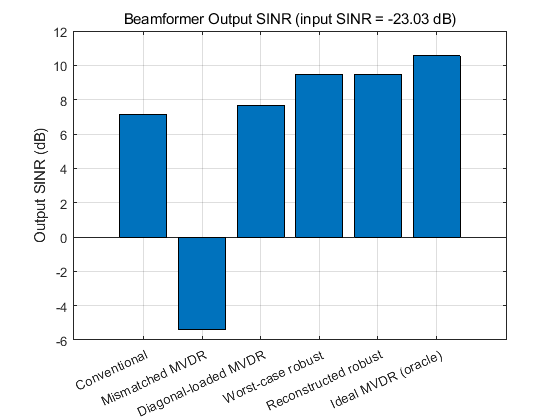

In [12]:

figure;
bar(output_sinr_dB);
grid on;
xticks(1:numel(beamformer));
xticklabels(beamformer);
xtickangle(25);
ylabel('Output SINR (dB)');
title(sprintf('Beamformer Output SINR (input SINR = %.2f dB)', ...
    input_sinr_dB));